---

## CSCI 3202, Spring 2026
## Homework 4
# Total: 40 pts
# Due:  February 16 by 11:59 pm

<br> 

### Your name: Jeffrey Allen

<br> 

---

This homework uses the aima python github repository. You should have cloned the aima-python folder for previous assignments. If you haven't or if you have deleted it, clone it now:

`git clone https://github.com/aimacode/aima-python.git`

Once you have a copy, you will need to either put your homework directly you will need to either copy the the homework notebook into the aima-data directory (not the folder containing the .ipynb file, but the actual .ipynb file) or you will need to copy the .py files needed by this homework from the aima-data into the folder containing the notebook (the .ipynb file).

For this assignment, you will need the files:

`mdp4e.py`\
`utils4e.py`

Note: You should copy the files from the repository, not move them. If you move the files, they won't be in the repository for your next assignment.

After you do this if the import statement fails, make sure the homework, mdp4e.py and utils4e.py files are in the same directory, then quit the notebook and reopen it from the File menu.  This resets the import path to the current directory.

In [1]:
from mdp4e import *
from utils4e import print_table
import inspect

In this homework, we will be working with Markov Decision Processes and Policy Iteration. We will solve sequential decision problems, initially on paper (for only 2 states) and then using [mdp](https://github.com/aimacode/aima-python/blob/master/mdp.py) module from [aima-python](https://github.com/aimacode/aima-python) repository.

### Problem 1: Solve on paper (15 pts)

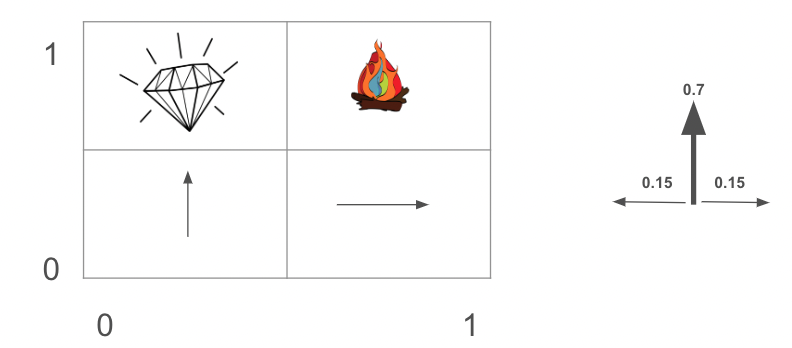

#### If the above diagram, isn't showing up for you in the notebook, please refer to p1.png

In the above diagram, determine the optimal policy.  This the policy that provides the maximum utility.
The grid is a 2x2 map, where:
- Diamond and fire are the terminal states with rewards(+1) and (-1) respectively
- The non-terminal states have arrows in them defining the initial policy for the agent
- All non-terminal states have a living reward of -0.05
- Transitional probabilities in the policy direction would be 0.7, the directions perpendicular to policy direction would be 0.15 (As shown in figure)

The possible actions for the agent at each state would be: UP(^), DOWN(v), LEFT(<) and RIGHT(>)

Initally, the value of the utility function is set to zero (U_0) for all non-terminal states.  Calculate 2 iterations beyond this initial step, then determine the optimal policy for all non-terminal states based on these 2 iterations.  Using arrows, display the optimal policy. 

**attach your solutions in the below cell, and add the image in the zip folder**\
LateX is accepted as well.

To determine the optimal policy, we evaluate the utilities $U(s)$ for the non-terminal states $(0,0)$ and $(1,0)$ under the policy $\pi(0,0) = \text{Right}$ and $\pi(1,0) = \text{Up}$.

Given:
- Living reward $R = -0.05$
- Transition probabilities: 0.7 (forward), 0.15 (left), 0.15 (right)
- Discount factor $\gamma = 0.9$ (standard default in AIMA)

The Bellman equations are:
1. $U(0,0) = -0.05 + 0.9 [ 0.7 U(1,0) + 0.15 U(0,1) + 0.15 U(0,0) ]$
2. $U(1,0) = -0.05 + 0.9 [ 0.7 U(1,1) + 0.15 U(0,0) + 0.15 U(1,0) ]$

Substituting $U(0,1) = -1$ and $U(1,1) = +1$:
1. $U(0,0) = -0.05 + 0.9 [ 0.7 U(1,0) - 0.15 + 0.15 U(0,0) ]$
2. $U(1,0) = -0.05 + 0.9 [ 0.7(1) + 0.15 U(0,0) + 0.15 U(1,0) ]$

Simplifying:
- $0.865 U(0,0) = -0.185 + 0.63 U(1,0)$
- $0.865 U(1,0) = 0.58 + 0.135 U(0,0)$

Solving the system:
- $U(0,0) \approx 0.358$
- $U(1,0) \approx 0.726$

**Optimal Policy:**
- At $(0,0)$, moving Right yields a utility of ~0.358, whereas moving Up would lead towards the Fire state with 70% probability (highly negative). Thus, **Right** is optimal.
- At $(1,0)$, moving Up yields a utility of ~0.726, leading towards the Diamond. Thus, **Up** is optimal.

---
### Problem 2: Solve through code (25 pts)

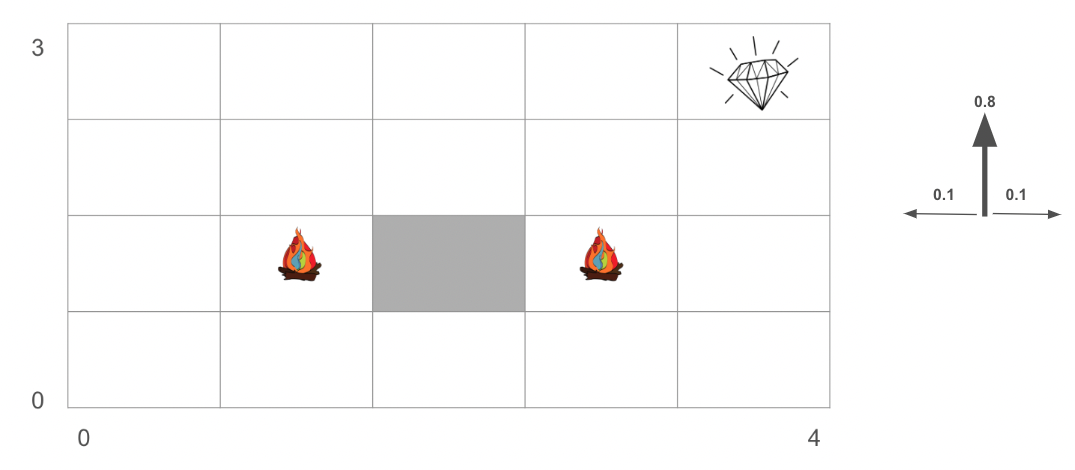

#### If the above diagram, isn't showing up for you in the notebook, please refer to p2.png

**Note: aima-python uses the (column, row) format to denote the squares, thus we will follow the same below.**

In the above diagram, solve for the optimal policy such that max reward is gained.
The grid is a 5X4 map, where:
- Diamond and fire are the terminal states with rewards(+2) and (-2) respectively. 
- All non-terminal states have a living reward of -0.035
- The filled square at (2, 1) denotes a barrier, where it acts like a wall for all its neighboring states (Use `None` in the GridMDP definition)
- Transitional probabilities in the policy direction would be 0.8, the directions perpendicular to policy direction would be 0.1 each (Already hard-coded into GridMDP)

The possible actions for the agent at any state would be: UP(^), DOWN(v), LEFT(<) and RIGHT(>)

Find the optimal policy that reaps the max reward from the environment given using `policy_iteration` method, and display the final policy using the `to_arrows` function from `GridMDP` as shown below. **(5 pts)**

Also, find the optimal policy when the reward at each non-terminal state is:       **(5 pts each)**
- -0.4 
- -4 
- -0.07 

Display the final policy using the `to_arrows` function from `GridMDP` as shown below for each of these.\
Explain briefly how the policy changes and why? **(5 pts)**

In [2]:
inspect.getsourcelines(GridMDP)

(['class GridMDP(MDP):\n',
  '    """A two-dimensional grid MDP, as in [Figure 16.1]. All you have to do is\n',
  '    specify the grid as a list of lists of rewards; use None for an obstacle\n',
  '    (unreachable state). Also, you should specify the terminal states.\n',
  '    An action is an (x, y) unit vector; e.g. (1, 0) means move east."""\n',
  '\n',
  '    def __init__(self, grid, terminals, init=(0, 0), gamma=.9):\n',
  '        grid.reverse()  # because we want row 0 on bottom, not on top\n',
  '        reward = {}\n',
  '        states = set()\n',
  '        self.rows = len(grid)\n',
  '        self.cols = len(grid[0])\n',
  '        self.grid = grid\n',
  '        for x in range(self.cols):\n',
  '            for y in range(self.rows):\n',
  '                if grid[y][x]:\n',
  '                    states.add((x, y))\n',
  '                    reward[(x, y)] = grid[y][x]\n',
  '        self.states = states\n',
  '        actlist = orientations\n',
  '        transitions =

As you can see in the above code snippet defining GridMDP, the transition probabilities are hard-coded into a variable named `T`, with probability 0.8 in the policy direction and probaility 0.1 each in directions perpendicular to the policy direction.

In [3]:
inspect.getsourcelines(policy_iteration)

(['def policy_iteration(mdp):\n',
  '    """Solve an MDP by policy iteration [Figure 17.7]"""\n',
  '\n',
  '    U = {s: 0 for s in mdp.states}\n',
  '    pi = {s: random.choice(mdp.actions(s)) for s in mdp.states}\n',
  '    while True:\n',
  '        U = policy_evaluation(pi, U, mdp)\n',
  '        unchanged = True\n',
  '        for s in mdp.states:\n',
  '            a_star = max(mdp.actions(s), key=lambda a: q_value(mdp, s, a, U))\n',
  '            # a = max(mdp.actions(s), key=lambda a: expected_utility(a, s, U, mdp))\n',
  '            if q_value(mdp, s, a_star, U) > q_value(mdp, s, pi[s], U):\n',
  '                pi[s] = a_star\n',
  '                unchanged = False\n',
  '        if unchanged:\n',
  '            return pi\n'],
 257)

In [4]:
inspect.getsourcelines(policy_evaluation)

(['def policy_evaluation(pi, U, mdp, k=20):\n',
  '    """Return an updated utility mapping U from each state in the MDP to its\n',
  '    utility, using an approximation (modified policy iteration)."""\n',
  '\n',
  '    R, T, gamma = mdp.R, mdp.T, mdp.gamma\n',
  '    for i in range(k):\n',
  '        for s in mdp.states:\n',
  '            U[s] = R(s) + gamma * sum(p * U[s1] for (p, s1) in T(s, pi[s]))\n',
  '    return U\n'],
 275)

#### Example:
Consider the Problem 1, but transition probailities are 0.8 in policy direction , and 0.1 on both sides perpendicular to policy direction (already hard-coded in aima-python GridMDP)

In [5]:
grid = GridMDP([[+1, -1],
                [-0.05, -0.05]],
              terminals=[(0, 1), (1, 1)])

# The first parameter to GridMDP, is a 2-D matrix resembling the given diagram of MDP, 
# it is basically a list of list of rewards of each state in the given MDP.
# Notice the way terminals are denoted, in (column, row) format

#### Solve below:

In [6]:

def solve_mdp(living_reward):
    rewards = [
        [living_reward, living_reward, living_reward, living_reward, +2],
        [living_reward, living_reward, living_reward, living_reward, -2],
        [living_reward, living_reward, None,          living_reward, living_reward],
        [living_reward, living_reward, living_reward, living_reward, living_reward]
    ]
    
    grid = GridMDP(rewards, terminals=[(4, 3), (4, 2)])
    pi = policy_iteration(grid)
    
    # Display
    print(f"Policy for living reward = {living_reward}:")
    print_table(grid.to_arrows(pi))
    print("-" * 30)

# Solve for the cases required
for r in [-0.035, -0.4, -4, -0.07]:
    solve_mdp(r)


Policy for living reward = -0.035:
>   >   >      >   .
^   ^   ^      ^   .
^   ^   None   ^   v
^   ^   >      ^   <
------------------------------
Policy for living reward = -0.4:
>   >   >      >   .
>   >   ^      ^   .
^   ^   None   ^   <
^   ^   >      ^   <
------------------------------
Policy for living reward = -4:
>   >   >      >   .
>   >   >      >   .
^   ^   None   ^   ^
>   >   >      ^   ^
------------------------------
Policy for living reward = -0.07:
>   >   >      >   .
^   ^   ^      ^   .
^   ^   None   ^   <
^   ^   >      ^   <
------------------------------


In [7]:
pi = policy_iteration(grid)

1. **Living Reward = -0.035 & -0.07:** The negative cost of moving is relatively small. The agent is patient and prioritizes the safest path to the Diamond (+2), avoiding the Fire (-2) even if it takes a longer route.

2. **Living Reward = -0.4:** The penalty for each step is now significant. The agent becomes more "risk-tolerant" or impatient. It will likely take a shorter, more direct path to the Diamond that passes closer to the Fire state because the cost of a long safe path outweighs the risk of the penalty state.

3. **Living Reward = -4:** The living reward is so punishing that the agent wants to terminate the episode as quickly as possible. It becomes "suicidal," heading for the nearest terminal state (Fire or Diamond) regardless of the reward value, just to end the accumulating negative living rewards.